# Ariel Data Challenge 2023 — EDA

**Docs**: https://www.ariel-datachallenge.space/ML/documentation/data

---

## What is this dataset?

Simulated exoplanet transmission spectra for the ESA ARIEL mission (launch 2029).  
Generated with **TauREx 3** (atmospheric model) + **ArielRad** (instrument simulator).

**Task**: Given a noisy spectrum + stellar/planetary features -> predict atmospheric composition.

## Input vs Output

### INPUT (both train & test)
| File | Content | Shape |
|------|---------|-------|
| `SpectralData.hdf5` | 52-bin transmission spectrum per planet | (N, 52, 4) |
| `AuxillaryTable.csv` | 8 stellar/planetary features | (N, 8) |

Spectral channels: wavelength, transit depth, noise, bin width

### OUTPUT / TARGETS (train only)
| File | Content |
|------|---------|
| `Tracedata.hdf5` | Full posterior distributions — only ~16% have actual traces, rest are empty |
| `QuartilesTable.csv` | q1/q2/q3 for 7 params (all 41,423 planets) |
| `FM_Parameter_Table.csv` | Forward model true params (all 41,423 planets) |

### 7 Target Parameters
planet_radius, T, log_H2O, log_CO2, log_CO, log_CH4, log_NH3

### CRITICAL: Test data has NO atmosphere labels
TestData (685 planets) has only spectra + auxiliary features. No ground truth.

## Setup

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('dark_background')
sns.set_palette('viridis')

ROOT = Path('../ariel-ml-dataset')
TRAIN = ROOT / 'TrainingData'
TEST = ROOT / 'TestData'
GT = TRAIN / 'Ground Truth Package'

## 1. Auxiliary Features

In [2]:
aux_train = pd.read_csv(TRAIN / 'AuxillaryTable.csv')
feat_cols = [c for c in aux_train.columns if c != 'planet_ID']
print(f'Shape: {aux_train.shape}')
print(f'Features: {feat_cols}')
aux_train.head()

Shape: (41423, 9)
Features: ['star_distance', 'star_mass_kg', 'star_radius_m', 'star_temperature', 'planet_mass_kg', 'planet_orbital_period', 'planet_distance', 'planet_surface_gravity']


,planet_ID,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity
0,train1,530.765,1.968526e+30,6.678720e+08,5636.0,3.990923e+26,9.668577,0.088530,16.642039
1,train2,440.089,1.948642e+30,7.235280e+08,5449.0,4.977001e+26,4.218028,0.050752,5.197135
2,train3,1126.370,2.147483e+30,7.791840e+08,5675.0,9.686804e+25,2.828042,0.040158,7.871718
3,train4,1257.160,2.048062e+30,7.374420e+08,5849.0,4.486340e+25,3.855604,0.048601,4.894681
4,train5,211.553,2.525281e+30,1.092249e+09,6200.0,2.416329e+26,3.076340,0.044833,5.870151


In [3]:
aux_train.describe()

,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity
count,41423.000000,4.142300e+04,4.142300e+04,41423.000000,4.142300e+04,41423.000000,41423.000000,41423.000000
mean,712.397824,1.991245e+30,7.642578e+08,5608.154413,7.471938e+26,15.278954,0.107928,13.621973
std,491.171075,4.604279e+29,2.983267e+08,621.528812,3.149388e+27,22.366836,0.084111,38.827523
min,6.531270,3.181456e+29,1.391400e+08,3050.000000,6.168095e+24,0.224195,0.006221,0.080551
25%,318.810000,1.729917e+30,5.843880e+08,5306.000000,4.688850e+25,4.317680,0.052131,6.192643
50%,639.411000,1.948642e+30,6.957000e+08,5695.000000,1.457616e+26,9.289710,0.084424,8.630901
75%,1002.120000,2.187251e+30,8.765820e+08,5991.000000,5.780954e+26,18.643577,0.135476,12.174258
max,7470.050000,6.193738e+30,4.723803e+09,10170.000000,2.732941e+29,1047.835600,2.025430,3569.024510


In [4]:
print('Missing values:')
missing = aux_train.isnull().sum()
print(missing[missing > 0] if missing.any() else 'None')

Missing values:
None


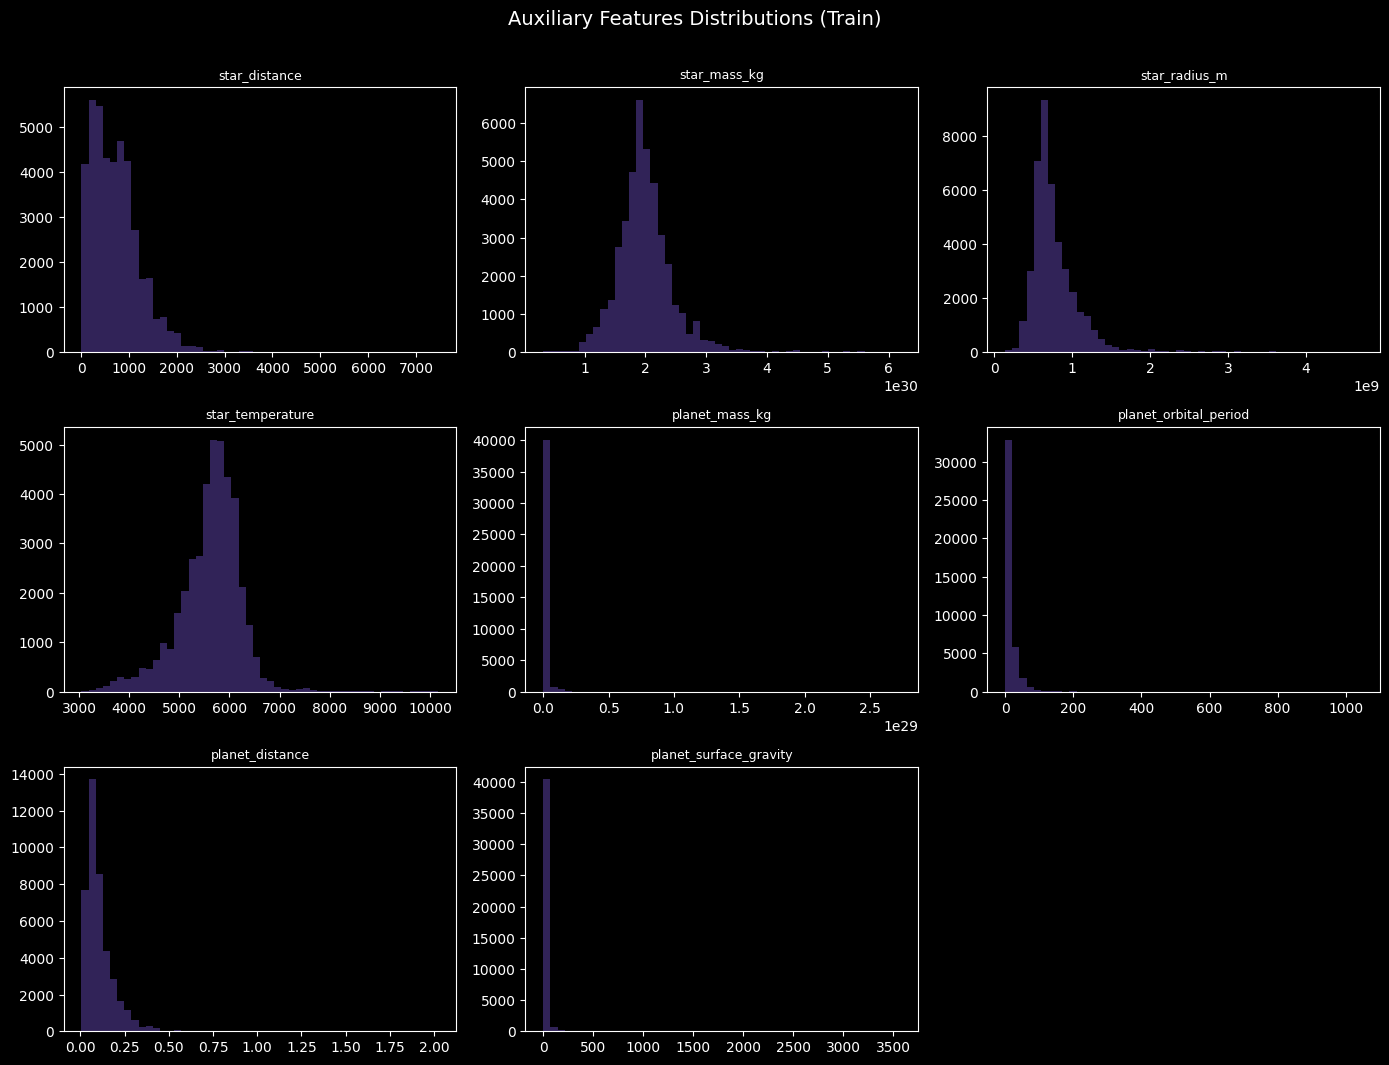

In [5]:
ncols = 3
nrows = (len(feat_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
for i, (ax, col) in enumerate(zip(axes.flat, feat_cols)):
    ax.hist(aux_train[col].dropna(), bins=50, alpha=0.7, edgecolor='none')
    ax.set_title(col, fontsize=9)
for j in range(i + 1, len(axes.flat)):
    axes.flat[j].set_visible(False)
plt.suptitle('Auxiliary Features Distributions (Train)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

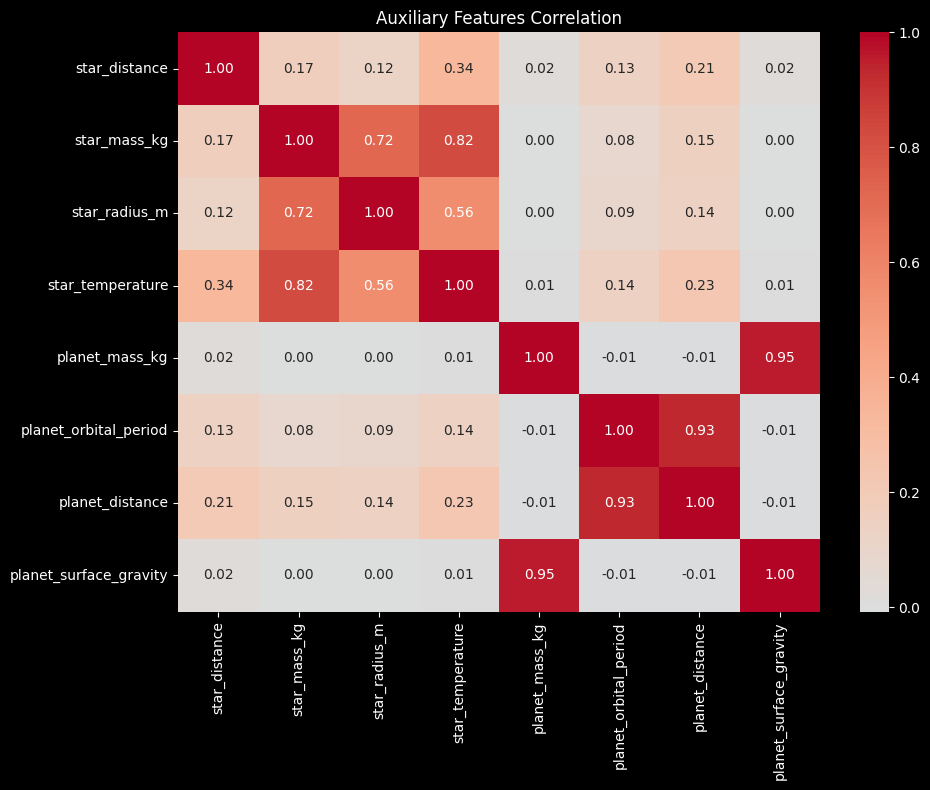

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(aux_train[feat_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Auxiliary Features Correlation')
plt.tight_layout()
plt.show()

## 2. Spectral Data

In [7]:
def load_spectra(hdf5_path, planet_ids):
    """Load spectra into (N, 52, 4): [wavelength, spectrum, noise, width]"""
    channels = ['instrument_wlgrid', 'instrument_spectrum',
                'instrument_noise', 'instrument_width']
    with h5py.File(hdf5_path, 'r') as f:
        spectra = np.empty((len(planet_ids), 52, 4))
        for idx, pid in enumerate(planet_ids):
            grp = f[f'Planet_{pid}']
            for ch_idx, ch in enumerate(channels):
                spectra[idx, :, ch_idx] = grp[ch][:]
    return spectra

planet_ids = aux_train['planet_ID'].values
spectra = load_spectra(TRAIN / 'SpectralData.hdf5', planet_ids)
print(f'Spectra shape: {spectra.shape}')

Spectra shape: (41423, 52, 4)


In [8]:
ch_names = ['wavelength (um)', 'transit depth', 'noise', 'bin width']
for i, name in enumerate(ch_names):
    v = spectra[:, :, i]
    print(f'{name:20s} | min: {v.min():.6f} | max: {v.max():.6f} | mean: {v.mean():.6f} | std: {v.std():.6f}')

wavelength (um)      | min: 0.550000 | max: 7.275559 | mean: 3.024755 | std: 1.481538
transit depth        | min: 0.000006 | max: 0.099579 | mean: 0.008258 | std: 0.011652
noise                | min: 0.000000 | max: 0.005591 | mean: 0.000073 | std: 0.000129
bin width            | min: 1.008333 | max: 7.410399 | mean: 4.464402 | std: 1.731247


In [9]:
wl = spectra[0, :, 0]
print(f'Wavelength range: {wl.min():.2f} - {wl.max():.2f} um ({len(wl)} bins)')
print(f'Grid identical across all planets: {np.all(spectra[:, :, 0] == wl)}')

Wavelength range: 0.55 - 7.28 um (52 bins)
Grid identical across all planets: True


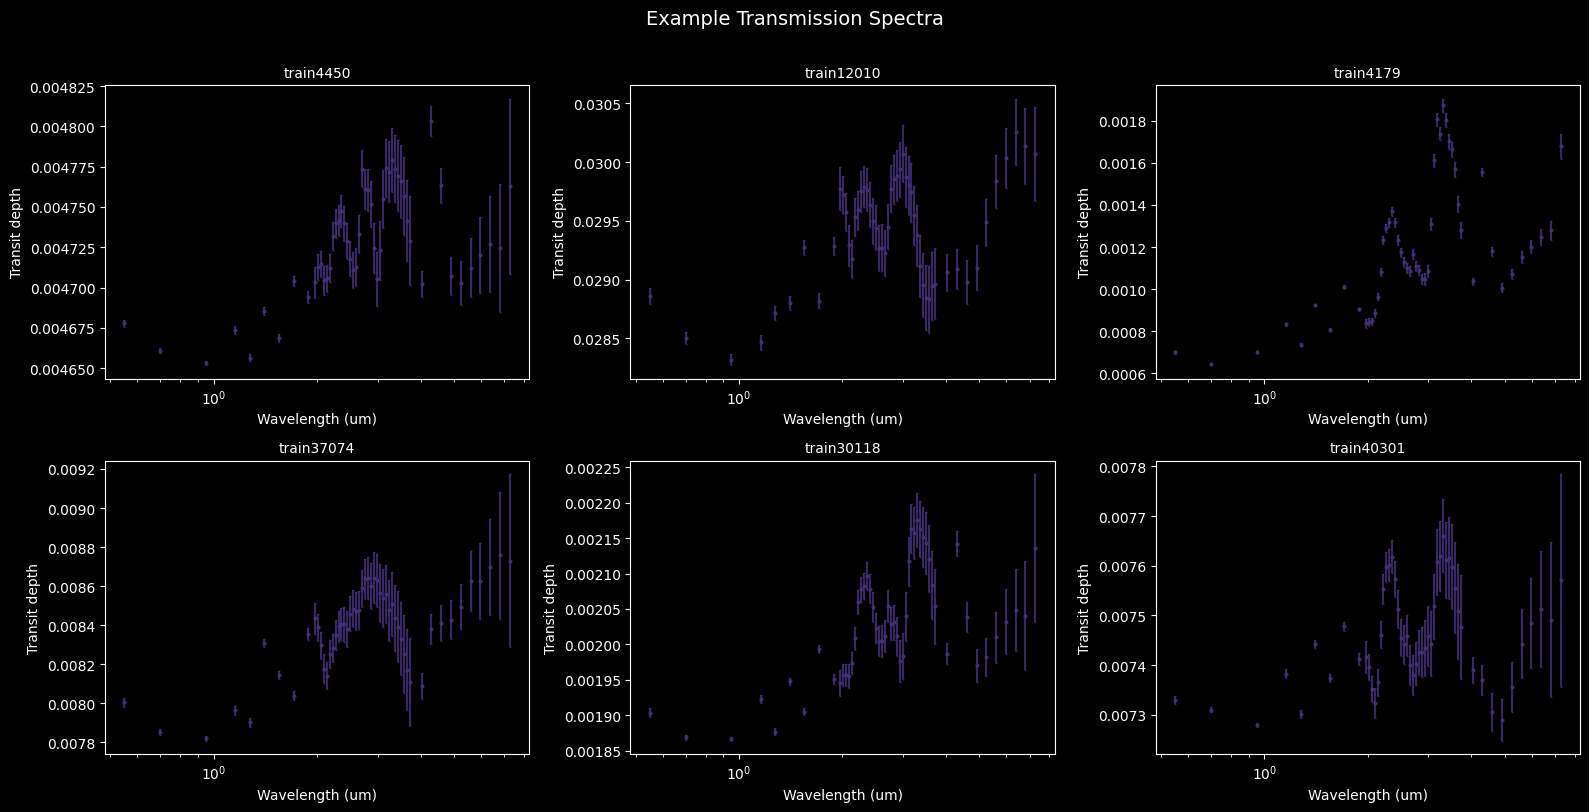

In [10]:
np.random.seed(42)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, idx in zip(axes.flat, np.random.choice(len(spectra), 6, replace=False)):
    ax.errorbar(spectra[idx, :, 0], spectra[idx, :, 1], yerr=spectra[idx, :, 2],
                fmt='o', markersize=2, capsize=1, alpha=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('Wavelength (um)')
    ax.set_ylabel('Transit depth')
    ax.set_title(f'{planet_ids[idx]}', fontsize=10)
plt.suptitle('Example Transmission Spectra', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

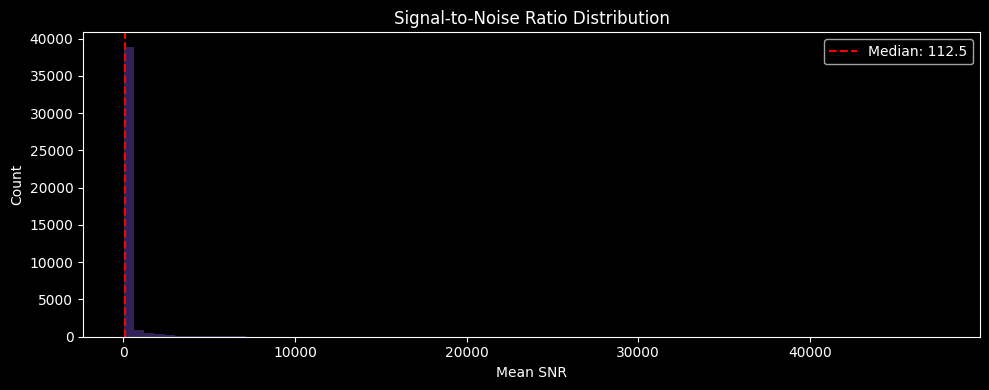

In [11]:
snr = np.mean(spectra[:, :, 1] / spectra[:, :, 2], axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(snr, bins=80, alpha=0.7, edgecolor='none')
ax.axvline(np.median(snr), color='red', ls='--', label=f'Median: {np.median(snr):.1f}')
ax.set_xlabel('Mean SNR')
ax.set_ylabel('Count')
ax.set_title('Signal-to-Noise Ratio Distribution')
ax.legend()
plt.tight_layout()
plt.show()

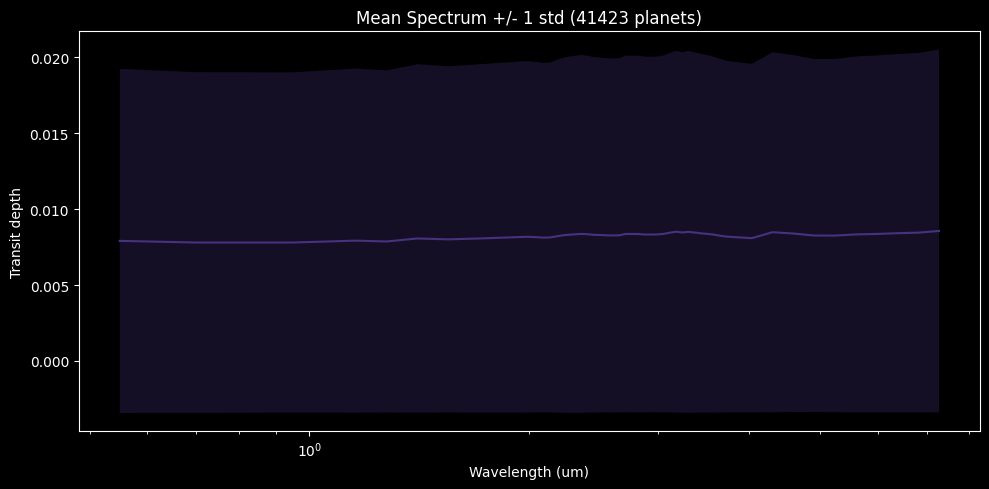

In [12]:
# Mean spectrum envelope across all planets
mean_spec = spectra[:, :, 1].mean(axis=0)
std_spec = spectra[:, :, 1].std(axis=0)
wl = spectra[0, :, 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(wl, mean_spec - std_spec, mean_spec + std_spec, alpha=0.3)
ax.plot(wl, mean_spec, lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Transit depth')
ax.set_title(f'Mean Spectrum +/- 1 std ({len(spectra)} planets)')
plt.tight_layout()
plt.show()

## 2b. Spectral Anatomy — Instrument Channels & Wavelength Regions

The 52 wavelength bins span **0.55–7.28 μm** across 6 ARIEL instrument channels:

| Channel | Bins | Wavelength (μm) | Count | Purpose |
|---------|------|-----------------|-------|---------|
| **VISPhot** | 0 | 0.55 | 1 | Photometry (visible) |
| **FGS1** | 1 | 0.70 | 1 | Fine guidance sensor |
| **FGS2** | 2 | 0.95 | 1 | Fine guidance sensor |
| **NIRSpec** | 3–8 | 1.16–1.88 | 6 | Near-IR spectrometer |
| **AIRS-Ch0** | 9–41 | 1.97–3.72 | 33 | Main spectrometer |
| **AIRS-Ch1** | 42–51 | 4.03–7.28 | 10 | Long-wave spectrometer |

Most spectral information comes from **AIRS-Ch0** (33 bins, highest resolution).

In [13]:
# Raw data sample — one planet's 52 bins with channel labels
CHANNELS = {
    'VISPhot': (0, 1), 'FGS1': (1, 2), 'FGS2': (2, 3),
    'NIRSpec': (3, 9), 'AIRS-Ch0': (9, 42), 'AIRS-Ch1': (42, 52)
}

def bin_to_channel(idx):
    for name, (lo, hi) in CHANNELS.items():
        if lo <= idx < hi:
            return name
    return '?'

wl = spectra[0, :, 0]
sample = pd.DataFrame({
    'bin': range(52),
    'wavelength_um': wl,
    'transit_depth': spectra[0, :, 1],
    'noise': spectra[0, :, 2],
    'bin_width': spectra[0, :, 3],
    'channel': [bin_to_channel(i) for i in range(52)]
})
print(f'=== Raw data for {planet_ids[0]} ===')
print(f'Shape per planet: (52, 4) = 52 wavelength bins x [wavelength, transit_depth, noise, bin_width]\n')
sample.style.background_gradient(subset=['transit_depth'], cmap='viridis')

=== Raw data for train1 ===
Shape per planet: (52, 4) = 52 wavelength bins x [wavelength, transit_depth, noise, bin_width]



,bin,wavelength_um,transit_depth,noise,bin_width,channel
0,0,0.550000,0.003836,0.000006,1.008333,VISPhot
1,1,0.700000,0.003834,0.000004,2.041667,FGS1
2,2,0.950000,0.003833,0.000003,3.076705,FGS2
3,3,1.156375,0.003854,0.000006,1.130186,NIRSpec
4,4,1.274903,0.003899,0.000006,1.246030,NIRSpec
5,5,1.405581,0.003901,0.000006,1.373748,NIRSpec
6,6,1.549653,0.003965,0.000006,1.514557,NIRSpec
7,7,1.708493,0.003903,0.000006,1.669800,NIRSpec
8,8,1.883613,0.003952,0.000008,1.840954,NIRSpec
9,9,1.969598,0.004017,0.000020,3.919888,AIRS-Ch0


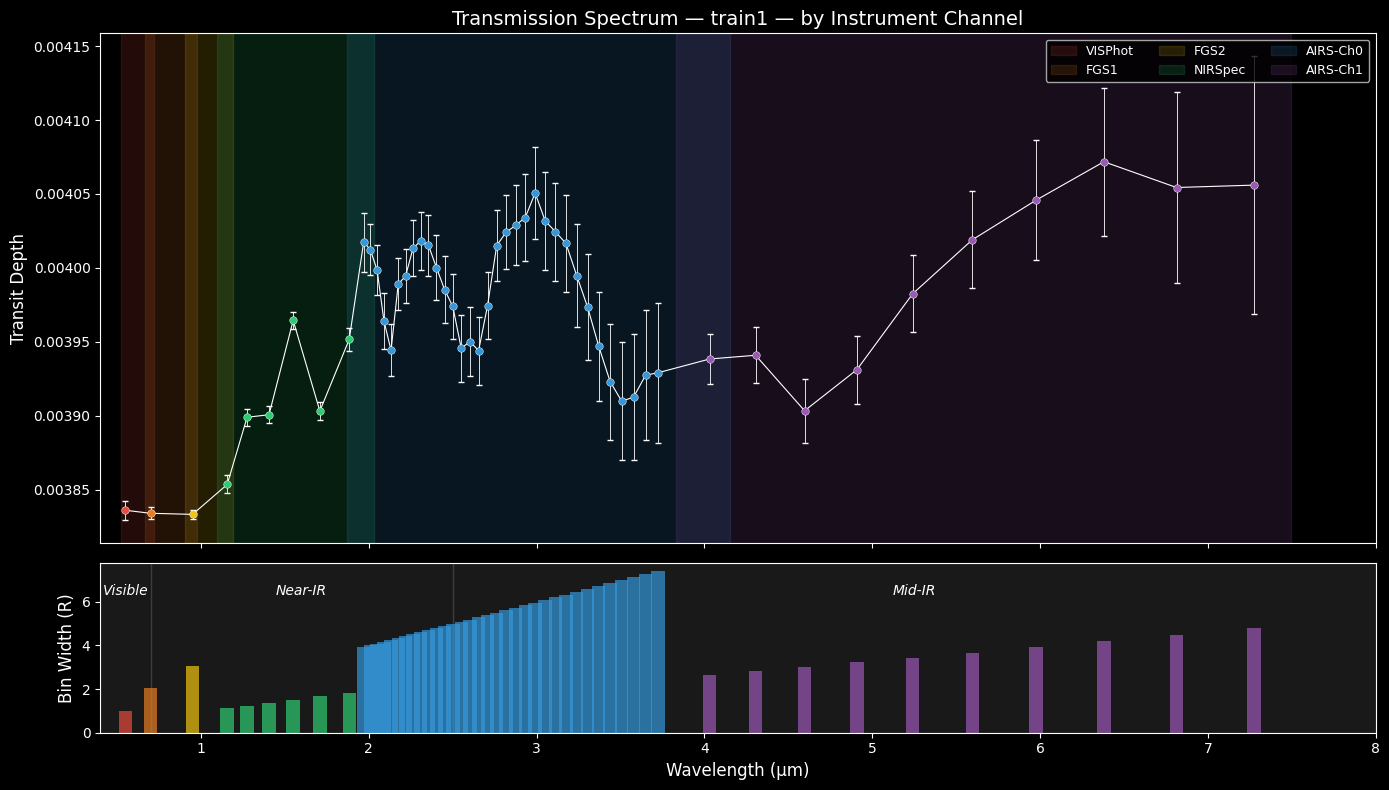

In [14]:
# Single spectrum with instrument channel bands + wavelength regions
CHANNEL_COLORS = {
    'VISPhot': '#e74c3c', 'FGS1': '#e67e22', 'FGS2': '#f1c40f',
    'NIRSpec': '#2ecc71', 'AIRS-Ch0': '#3498db', 'AIRS-Ch1': '#9b59b6'
}
WL_REGIONS = [
    (0.4, 0.7, 'Visible'),
    (0.7, 2.5, 'Near-IR'),
    (2.5, 8.0, 'Mid-IR'),
]

idx = 0
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                      gridspec_kw={'height_ratios': [3, 1]})

# Top: spectrum with channel background bands
for ch_name, (lo, hi) in CHANNELS.items():
    wl_lo = spectra[idx, lo, 0] * 0.95
    wl_hi = spectra[idx, min(hi, 51), 0] * 1.03 if hi < 52 else spectra[idx, 51, 0] * 1.03
    ax_top.axvspan(wl_lo, wl_hi, alpha=0.15, color=CHANNEL_COLORS[ch_name], label=ch_name)

ax_top.errorbar(spectra[idx, :, 0], spectra[idx, :, 1], yerr=spectra[idx, :, 2],
                fmt='o-', markersize=4, capsize=2, color='white', linewidth=0.8, elinewidth=0.6)

for ch_name, (lo, hi) in CHANNELS.items():
    mask = slice(lo, hi)
    ax_top.scatter(spectra[idx, mask, 0], spectra[idx, mask, 1],
                   s=30, color=CHANNEL_COLORS[ch_name], zorder=5, edgecolors='white', linewidths=0.3)

ax_top.set_ylabel('Transit Depth', fontsize=12)
ax_top.set_title(f'Transmission Spectrum — {planet_ids[idx]} — by Instrument Channel', fontsize=14)
ax_top.legend(loc='upper right', fontsize=9, ncol=3)

# Bottom: wavelength regions + bin width
for wl_lo, wl_hi, label in WL_REGIONS:
    ax_bot.axvspan(wl_lo, wl_hi, alpha=0.2, color='gray')
    ax_bot.text((wl_lo + wl_hi) / 2, spectra[idx, :, 3].max() * 0.85, label,
                ha='center', fontsize=10, style='italic', color='white')

ax_bot.bar(spectra[idx, :, 0], spectra[idx, :, 3], width=0.08, alpha=0.7,
           color=[CHANNEL_COLORS[bin_to_channel(i)] for i in range(52)])
ax_bot.set_xlabel('Wavelength (μm)', fontsize=12)
ax_bot.set_ylabel('Bin Width (R)', fontsize=12)
ax_bot.set_xlim(0.4, 8.0)

plt.tight_layout()
plt.show()

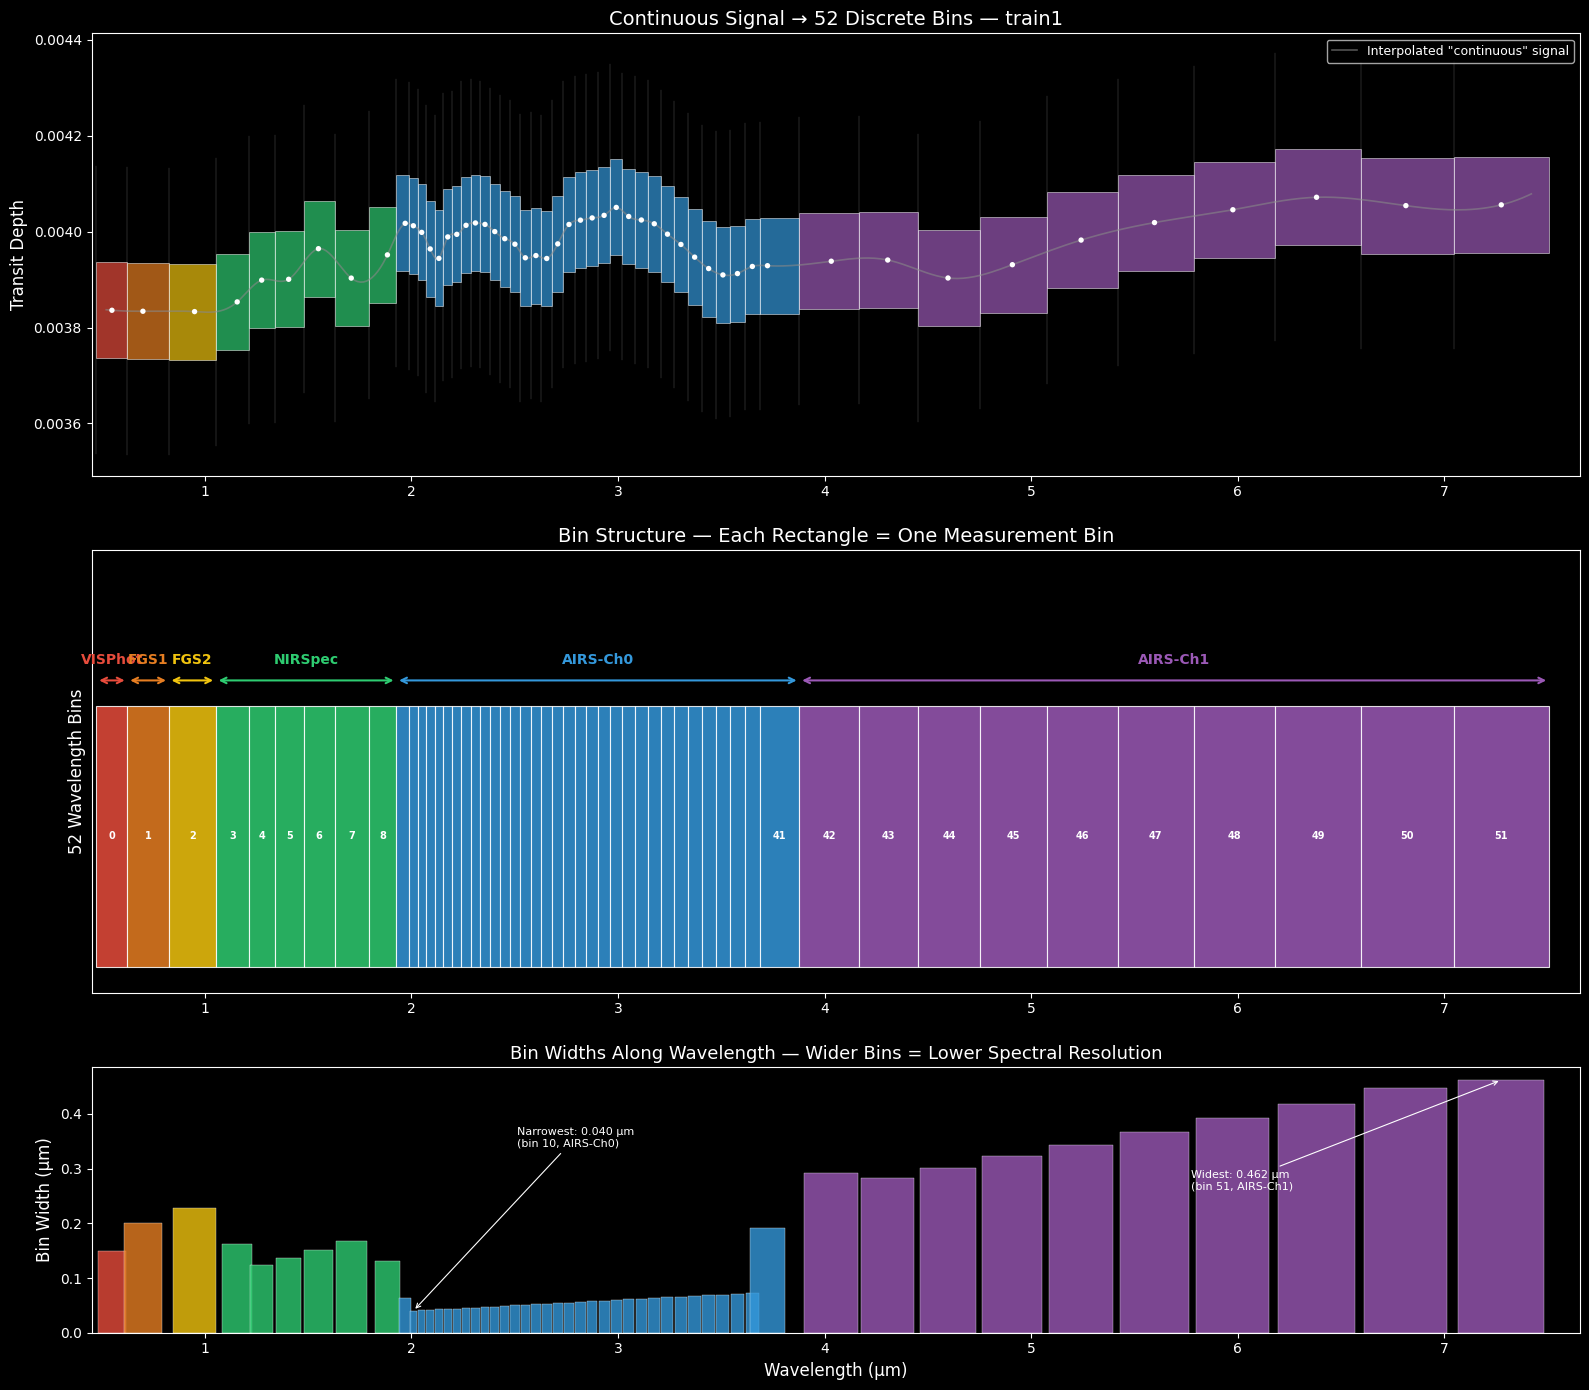


=== Binning Summary ===
Total bins: 52
Wavelength range: 0.475 – 7.506 μm
Bin widths: 0.0400 – 0.4618 μm

Per channel:
  VISPhot   : bins  0– 0 | 0.475–0.625 μm | bin Δλ: 0.1500–0.1500 μm | n=1
  FGS1      : bins  1– 1 | 0.625–0.825 μm | bin Δλ: 0.2000–0.2000 μm | n=1
  FGS2      : bins  2– 2 | 0.825–1.053 μm | bin Δλ: 0.2282–0.2282 μm | n=1
  NIRSpec   : bins  3– 8 | 1.053–1.927 μm | bin Δλ: 0.1246–0.1670 μm | n=6
  AIRS-Ch0  : bins  9–41 | 1.927–3.878 μm | bin Δλ: 0.0400–0.1910 μm | n=33
  AIRS-Ch1  : bins 42–51 | 3.878–7.506 μm | bin Δλ: 0.2826–0.4618 μm | n=10


In [15]:
# How the continuous spectrum is BINNED into 52 discrete bins
# Shows the exact wavelength coverage of each bin as a rectangle

idx = 0
wl = spectra[idx, :, 0]
depth = spectra[idx, :, 1]

# Compute bin edges from midpoints between adjacent wavelength centers
edges = np.zeros(53)
edges[1:-1] = (wl[:-1] + wl[1:]) / 2
edges[0] = wl[0] - (edges[1] - wl[0])
edges[-1] = wl[-1] + (wl[-1] - edges[-2])

# Interpolated "continuous" spectrum for background reference
from scipy.interpolate import make_interp_spline
wl_fine = np.linspace(wl.min() * 0.95, wl.max() * 1.02, 500)
try:
    spl = make_interp_spline(wl, depth, k=3)
    depth_fine = spl(wl_fine)
except:
    depth_fine = np.interp(wl_fine, wl, depth)

fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                         gridspec_kw={'height_ratios': [2, 2, 1.2]})

# --- Panel 1: Continuous vs Binned ---
ax = axes[0]
ax.plot(wl_fine, depth_fine, color='#888888', lw=1.2, alpha=0.6, label='Interpolated "continuous" signal')

for i in range(52):
    ch = bin_to_channel(i)
    color = CHANNEL_COLORS[ch]
    left, right = edges[i], edges[i + 1]
    ax.add_patch(plt.Rectangle((left, depth[i] - 0.0001), right - left, 0.0002,
                                facecolor=color, edgecolor='white', linewidth=0.5, alpha=0.7))
    ax.plot([left, left], [depth[i] - 0.0003, depth[i] + 0.0003],
            color='white', lw=0.3, alpha=0.4)

ax.scatter(wl, depth, s=15, color='white', zorder=10, edgecolors='none')
ax.set_ylabel('Transit Depth', fontsize=12)
ax.set_title(f'Continuous Signal \u2192 52 Discrete Bins \u2014 {planet_ids[idx]}', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(edges[0] * 0.95, edges[-1] * 1.02)

# --- Panel 2: Bin boxes \u2014 explicit rectangles showing coverage ---
ax = axes[1]
y_base = 0
bar_height = 1

for i in range(52):
    ch = bin_to_channel(i)
    color = CHANNEL_COLORS[ch]
    left, right = edges[i], edges[i + 1]
    width_um = right - left

    rect = plt.Rectangle((left, y_base), width_um, bar_height,
                          facecolor=color, edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.add_patch(rect)

    if width_um > 0.12:
        ax.text(left + width_um / 2, 0.5, str(i),
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')

# Channel labels on top
for ch_name, (lo, hi) in CHANNELS.items():
    mid_wl = (edges[lo] + edges[hi]) / 2
    ax.text(mid_wl, 1.15, ch_name, ha='center', va='bottom', fontsize=10,
            color=CHANNEL_COLORS[ch_name], fontweight='bold')
    ax.annotate('', xy=(edges[lo], 1.1), xytext=(edges[hi], 1.1),
                arrowprops=dict(arrowstyle='<->', color=CHANNEL_COLORS[ch_name], lw=1.5))

ax.set_ylim(-0.1, 1.6)
ax.set_xlim(edges[0] * 0.95, edges[-1] * 1.02)
ax.set_yticks([])
ax.set_ylabel('52 Wavelength Bins', fontsize=12)
ax.set_title('Bin Structure \u2014 Each Rectangle = One Measurement Bin', fontsize=14)

# --- Panel 3: Bin widths in \u03bcm ---
ax = axes[2]
bin_widths_um = np.diff(edges)
bars = ax.bar(wl, bin_widths_um, width=bin_widths_um * 0.9, alpha=0.8,
              color=[CHANNEL_COLORS[bin_to_channel(i)] for i in range(52)],
              edgecolor='white', linewidth=0.3)

ax.set_xlabel('Wavelength (\u03bcm)', fontsize=12)
ax.set_ylabel('Bin Width (\u03bcm)', fontsize=12)
ax.set_title('Bin Widths Along Wavelength \u2014 Wider Bins = Lower Spectral Resolution', fontsize=13)
ax.set_xlim(edges[0] * 0.95, edges[-1] * 1.02)

# Annotate extremes
narrowest = np.argmin(bin_widths_um)
widest = np.argmax(bin_widths_um)
ax.annotate(f'Narrowest: {bin_widths_um[narrowest]:.3f} \u03bcm\n(bin {narrowest}, {bin_to_channel(narrowest)})',
            xy=(wl[narrowest], bin_widths_um[narrowest]), xytext=(wl[narrowest] + 0.5, bin_widths_um[narrowest] + 0.3),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='white', lw=0.8), color='white')
ax.annotate(f'Widest: {bin_widths_um[widest]:.3f} \u03bcm\n(bin {widest}, {bin_to_channel(widest)})',
            xy=(wl[widest], bin_widths_um[widest]), xytext=(wl[widest] - 1.5, bin_widths_um[widest] - 0.2),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='white', lw=0.8), color='white')

plt.tight_layout(h_pad=2)
plt.show()

print(f'\n=== Binning Summary ===')
print(f'Total bins: 52')
print(f'Wavelength range: {edges[0]:.3f} \u2013 {edges[-1]:.3f} \u03bcm')
print(f'Bin widths: {bin_widths_um.min():.4f} \u2013 {bin_widths_um.max():.4f} \u03bcm')
print(f'\nPer channel:')
for ch_name, (lo, hi) in CHANNELS.items():
    ch_widths = bin_widths_um[lo:hi]
    print(f'  {ch_name:10s}: bins {lo:2d}\u2013{hi-1:2d} | {edges[lo]:.3f}\u2013{edges[hi]:.3f} \u03bcm | '
          f'bin \u0394\u03bb: {ch_widths.min():.4f}\u2013{ch_widths.max():.4f} \u03bcm | n={hi-lo}')

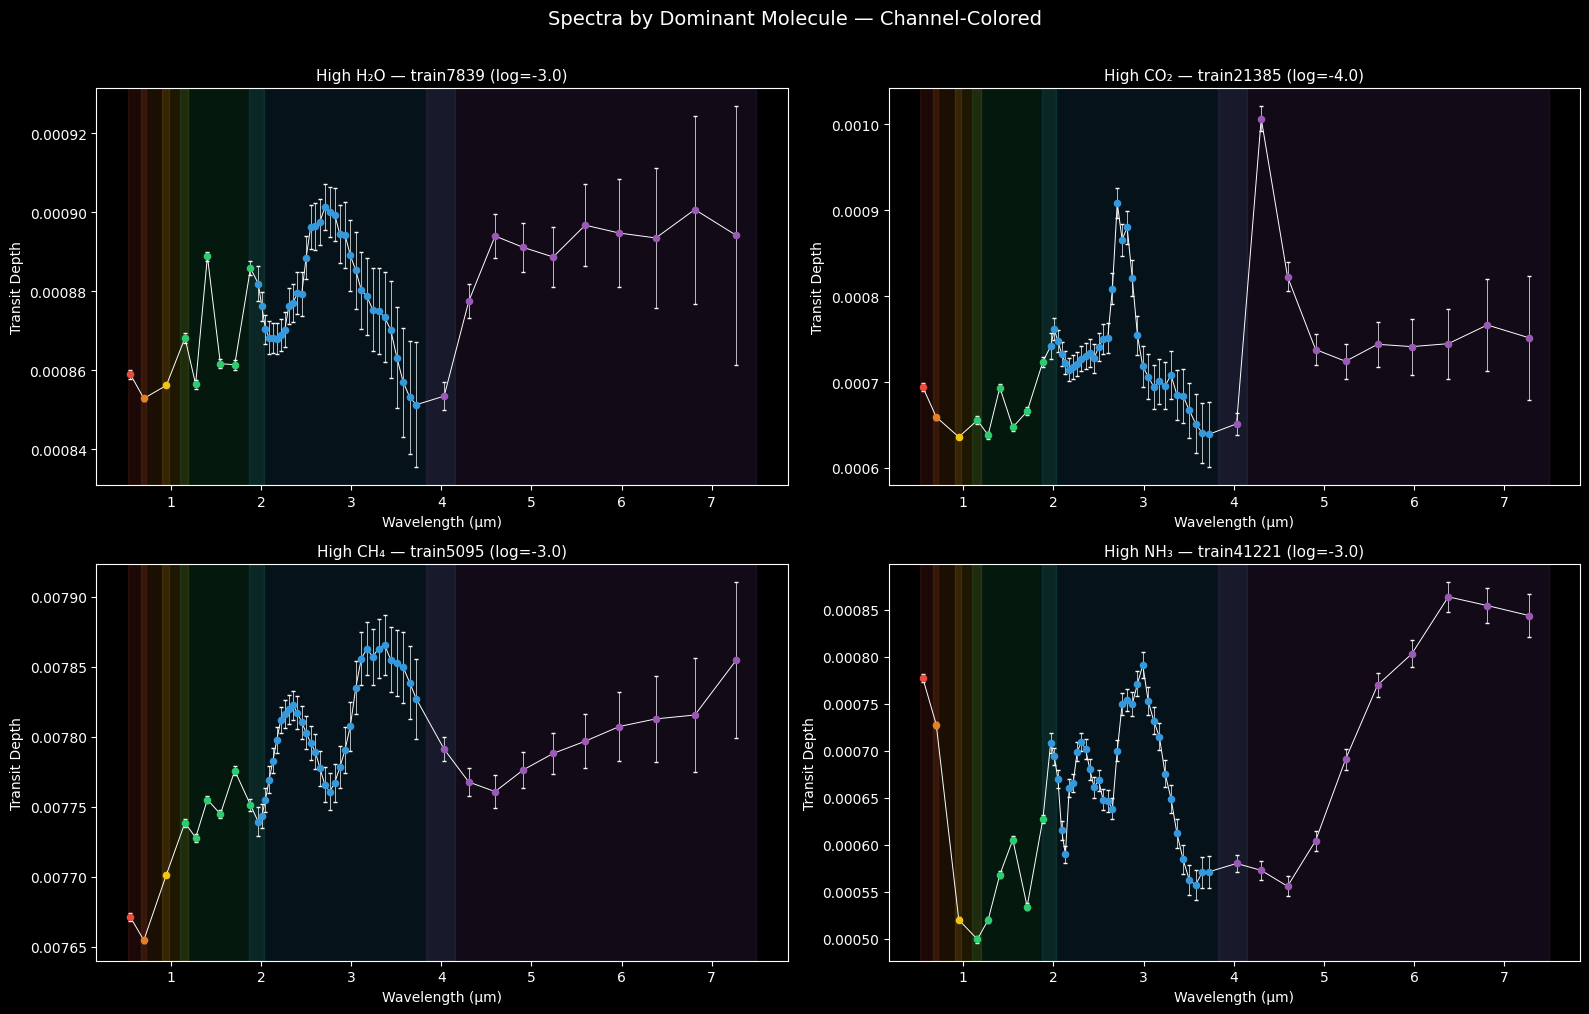

In [16]:
# Multi-planet comparison: spectra grouped by dominant molecule
fm_local = pd.read_csv(GT / 'FM_Parameter_Table.csv')
mol_cols = {'H₂O': 'log_H2O', 'CO₂': 'log_CO2', 'CH₄': 'log_CH4', 'NH₃': 'log_NH3'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (mol_label, mol_col) in zip(axes.flat, mol_cols.items()):
    top_idx = fm_local[mol_col].nlargest(1).index[0]
    pid = fm_local.loc[top_idx, 'planet_ID']
    spec_idx = np.where(planet_ids == pid)[0][0]

    for ch_name, (lo, hi) in CHANNELS.items():
        wl_lo = spectra[spec_idx, lo, 0] * 0.95
        wl_hi = spectra[spec_idx, min(hi, 51), 0] * 1.03 if hi < 52 else spectra[spec_idx, 51, 0] * 1.03
        ax.axvspan(wl_lo, wl_hi, alpha=0.12, color=CHANNEL_COLORS[ch_name])

    ax.errorbar(spectra[spec_idx, :, 0], spectra[spec_idx, :, 1], yerr=spectra[spec_idx, :, 2],
                fmt='o-', markersize=3, capsize=1.5, color='white', linewidth=0.7, elinewidth=0.5)

    for ch_name, (lo, hi) in CHANNELS.items():
        ax.scatter(spectra[spec_idx, lo:hi, 0], spectra[spec_idx, lo:hi, 1],
                   s=20, color=CHANNEL_COLORS[ch_name], zorder=5)

    abundance = fm_local.loc[top_idx, mol_col]
    ax.set_title(f'High {mol_label} — {pid} (log={abundance:.1f})', fontsize=11)
    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Transit Depth')

plt.suptitle('Spectra by Dominant Molecule — Channel-Colored', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Ground Truth — Quartiles

In [17]:
quartiles = pd.read_csv(GT / 'QuartilesTable.csv')
nan_rows = quartiles.isnull().any(axis=1).sum()
valid_rows = len(quartiles) - nan_rows
print(f'Quartiles: {quartiles.shape}')
print(f'Valid: {valid_rows} / {len(quartiles)} ({valid_rows/len(quartiles)*100:.1f}%)')
print(f'NaN rows: {nan_rows} ({nan_rows/len(quartiles)*100:.1f}%)')
print(f'Columns: {quartiles.columns.tolist()}')
quartiles.head()

Quartiles: (41423, 22)
Valid: 6766 / 41423 (16.3%)
NaN rows: 34657 (83.7%)
Columns: ['planet_ID', 'planet_radius_q1', 'planet_radius_q2', 'planet_radius_q3', 'T_q1', 'T_q2', 'T_q3', 'log_H2O_q1', 'log_H2O_q2', 'log_H2O_q3', 'log_CO2_q1', 'log_CO2_q2', 'log_CO2_q3', 'log_CO_q1', 'log_CO_q2', 'log_CO_q3', 'log_CH4_q1', 'log_CH4_q2', 'log_CH4_q3', 'log_NH3_q1', 'log_NH3_q2', 'log_NH3_q3']


,planet_ID,planet_radius_q1,planet_radius_q2,planet_radius_q3,T_q1,T_q2,T_q3,log_H2O_q1,log_H2O_q2,log_H2O_q3,...,log_CO2_q3,log_CO_q1,log_CO_q2,log_CO_q3,log_CH4_q1,log_CH4_q2,log_CH4_q3,log_NH3_q1,log_NH3_q2,log_NH3_q3
0,train1,0.567402,0.567710,0.568010,844.415505,866.914296,891.333831,-11.077151,-9.133313,-7.140711,...,-7.646653,-10.752979,-8.284487,-6.090059,-11.091584,-9.329650,-7.366853,-4.427620,-4.341881,-4.257781
1,train2,1.155672,1.157665,1.159610,1581.281312,1629.327207,1682.448127,-7.131470,-6.775547,-6.586242,...,-9.607456,-11.182463,-9.491758,-7.478319,-11.354370,-9.923588,-8.600297,-5.915788,-5.854696,-5.789745
2,train3,0.472299,0.473788,0.475347,425.392845,462.864034,523.215706,-11.045504,-9.160778,-7.431597,...,-4.781829,-3.198969,-2.255593,-1.498201,-11.057868,-9.350752,-7.731318,-11.140605,-9.445211,-7.835728
3,train4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,train5,0.743844,0.746010,0.748053,1804.495205,1849.044545,1895.224100,-4.796816,-4.705085,-4.609720,...,-7.955252,-4.395379,-3.938341,-3.556368,-10.973865,-8.443633,-6.632119,-5.157509,-5.076485,-4.989395


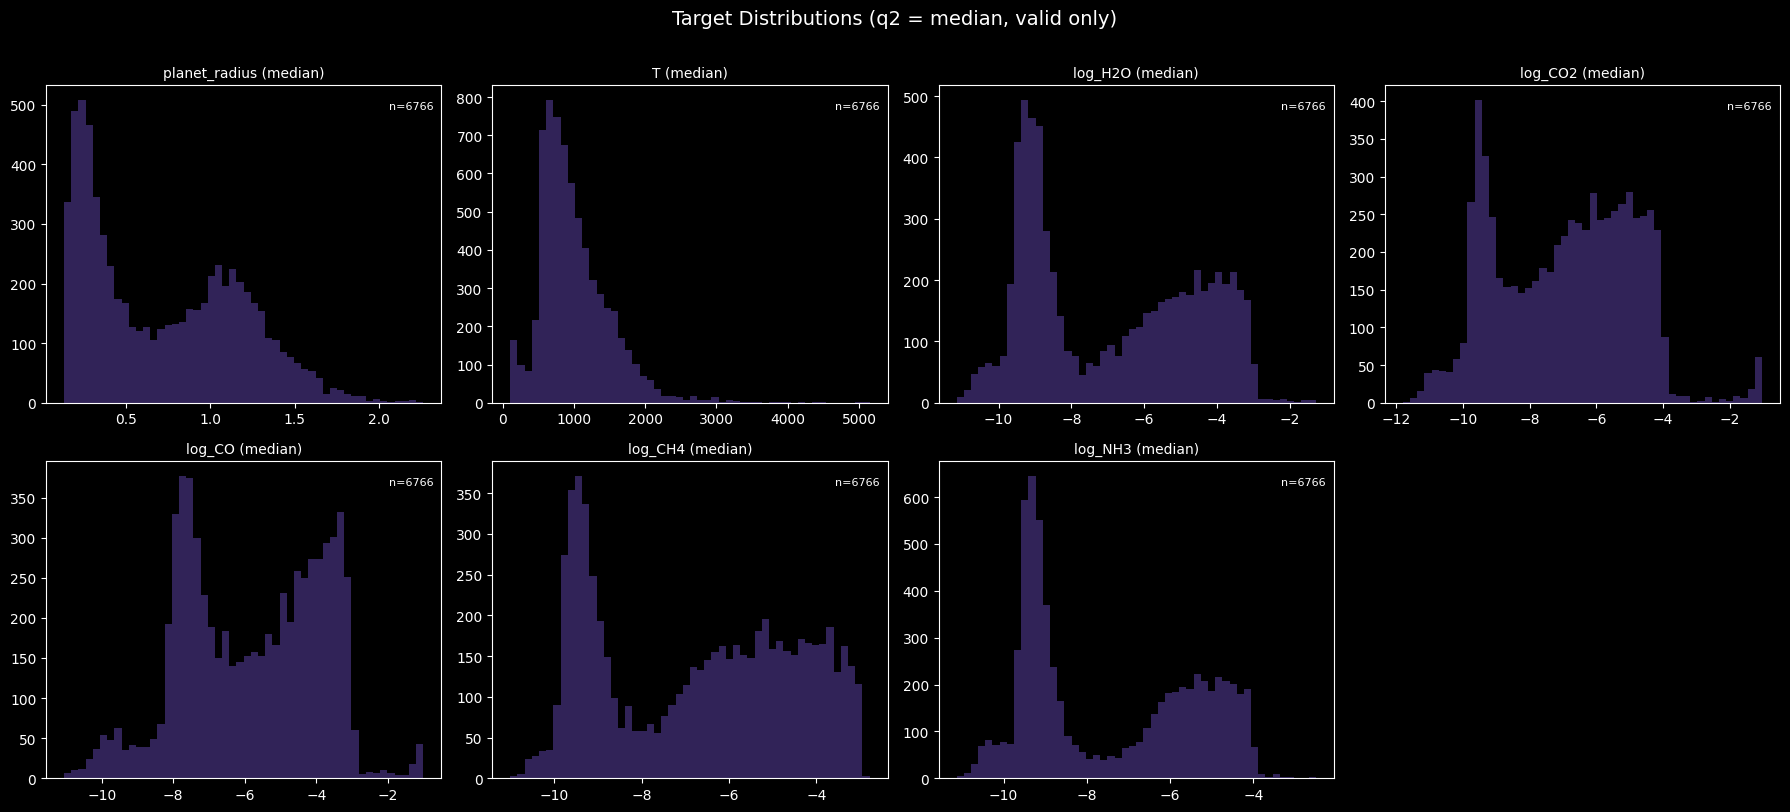

In [18]:
targets = ['planet_radius', 'T', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, t in zip(axes.flat[:7], targets):
    col = f'{t}_q2'
    if col in quartiles.columns:
        data = quartiles[col].dropna()
        ax.hist(data, bins=50, alpha=0.7, edgecolor='none')
        ax.set_title(f'{t} (median)', fontsize=10)
        ax.text(0.98, 0.95, f'n={len(data)}', transform=ax.transAxes, ha='right', va='top', fontsize=8)
axes.flat[-1].set_visible(False)
plt.suptitle('Target Distributions (q2 = median, valid only)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

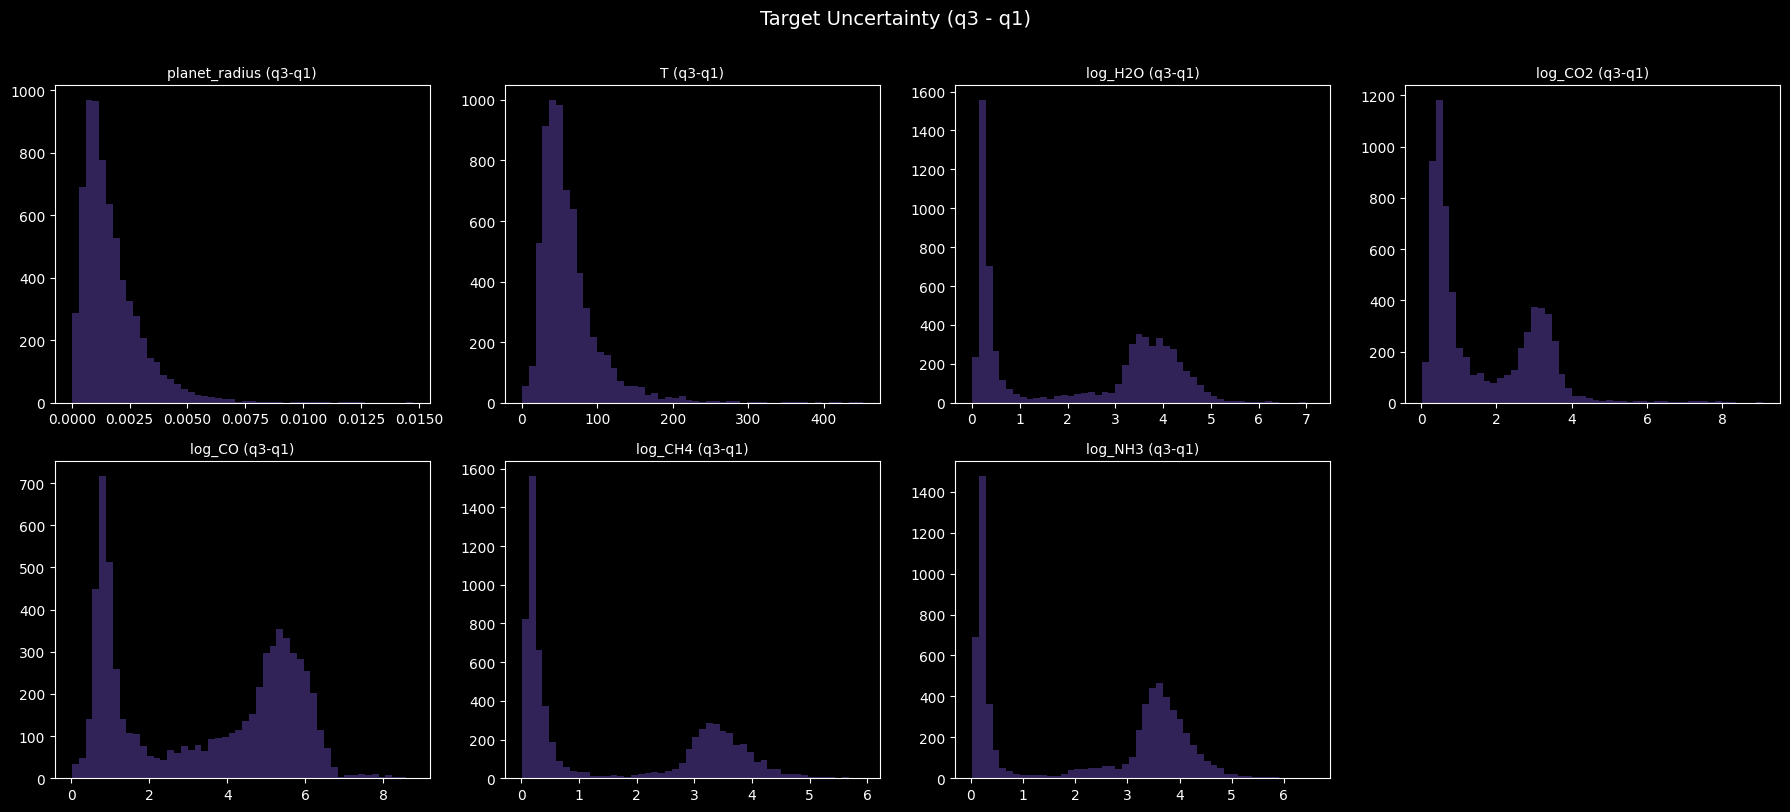

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, t in zip(axes.flat[:7], targets):
    q1, q3 = f'{t}_q1', f'{t}_q3'
    if q1 in quartiles.columns:
        ax.hist(quartiles[q3] - quartiles[q1], bins=50, alpha=0.7, edgecolor='none')
        ax.set_title(f'{t} (q3-q1)', fontsize=10)
axes.flat[-1].set_visible(False)
plt.suptitle('Target Uncertainty (q3 - q1)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. FM Parameters (Forward Model True Inputs)

In [20]:
fm = pd.read_csv(GT / 'FM_Parameter_Table.csv')
fm_cols = [c for c in fm.columns if c not in ['Unnamed: 0', 'planet_ID']]
print(f'Shape: {fm.shape}')
print(f'Params: {fm_cols}')
fm.head()

Shape: (41423, 9)
Params: ['planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']


,Unnamed: 0,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,2,train3,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,3,train4,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,4,train5,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345


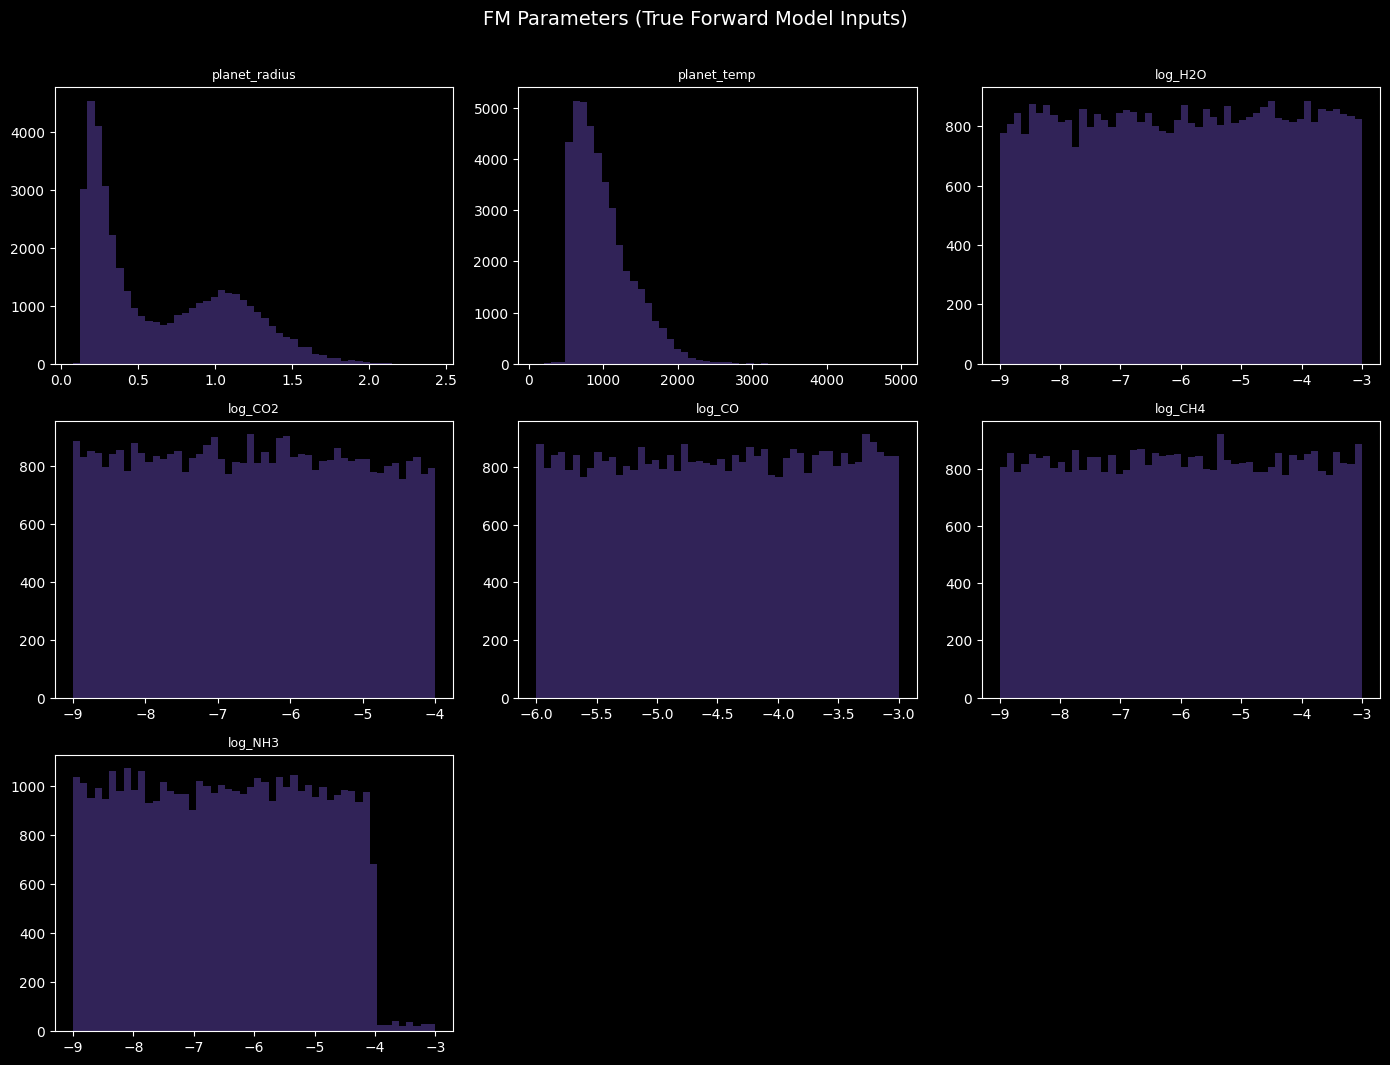

In [21]:
ncols = 3
nrows = (len(fm_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
for i, (ax, col) in enumerate(zip(axes.flat, fm_cols)):
    ax.hist(fm[col].dropna(), bins=50, alpha=0.7, edgecolor='none')
    ax.set_title(col, fontsize=9)
for j in range(i + 1, len(axes.flat)):
    axes.flat[j].set_visible(False)
plt.suptitle('FM Parameters (True Forward Model Inputs)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4b. FM Truth vs Retrieved Quartiles

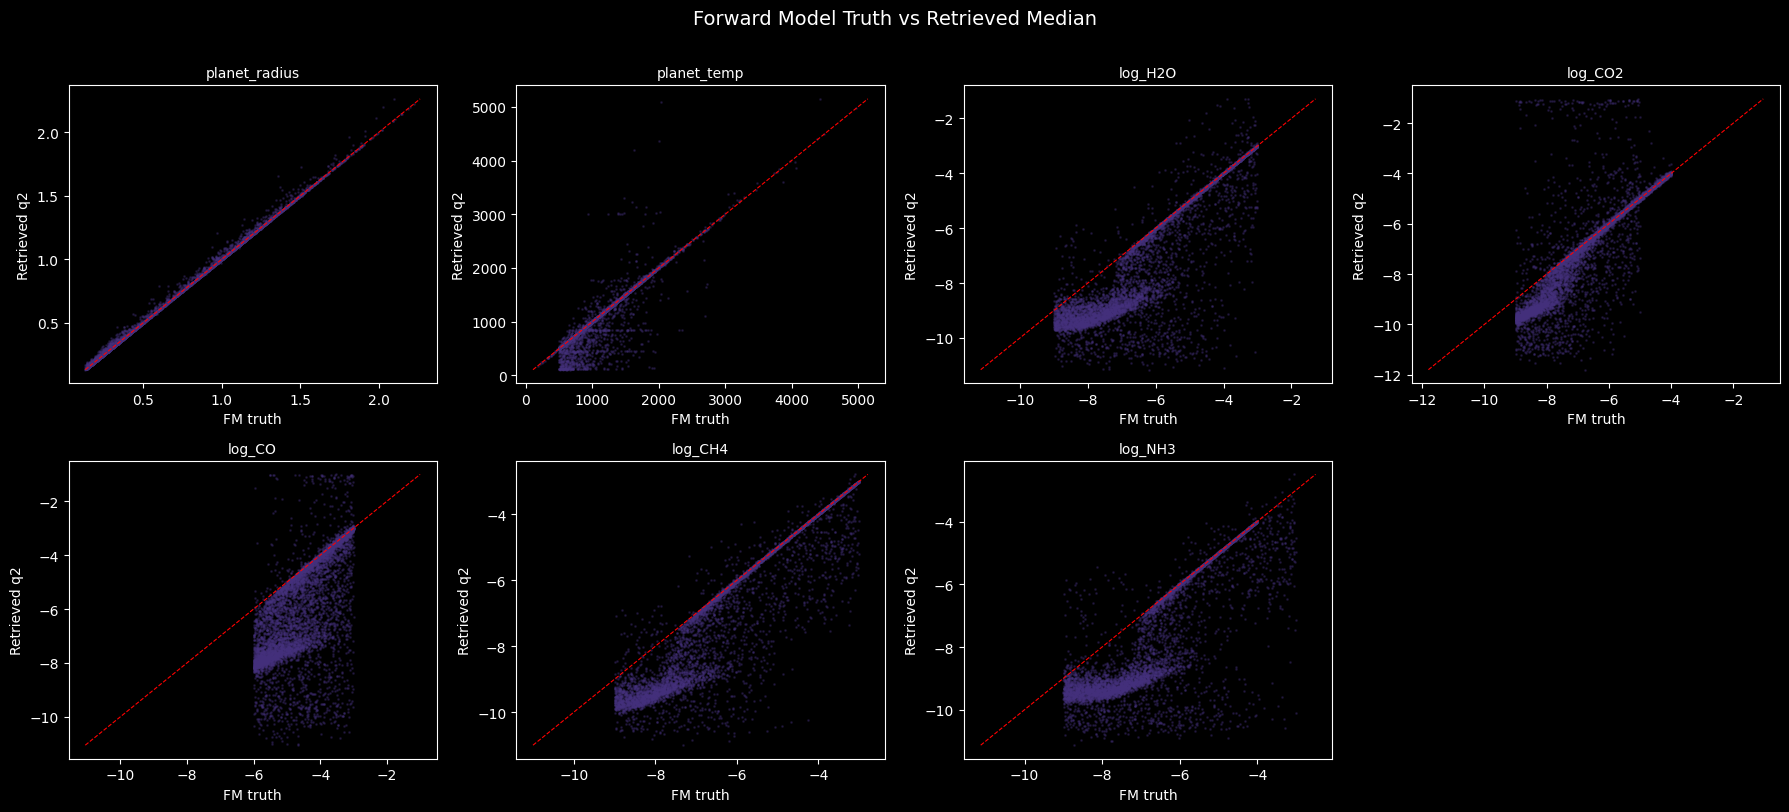

In [22]:
# FM truth vs retrieved quartile medians
merged = fm.merge(quartiles, on='planet_ID')
fm_names = ['planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
q_names = ['planet_radius_q2', 'T_q2', 'log_H2O_q2', 'log_CO2_q2', 'log_CO_q2', 'log_CH4_q2', 'log_NH3_q2']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, fm_col, q_col in zip(axes.flat[:7], fm_names, q_names):
    valid = merged[q_col].notna()
    ax.scatter(merged.loc[valid, fm_col], merged.loc[valid, q_col], s=1, alpha=0.3)
    lims = [min(merged.loc[valid, fm_col].min(), merged.loc[valid, q_col].min()),
            max(merged.loc[valid, fm_col].max(), merged.loc[valid, q_col].max())]
    ax.plot(lims, lims, 'r--', lw=0.8)
    ax.set_xlabel(f'FM truth')
    ax.set_ylabel(f'Retrieved q2')
    ax.set_title(fm_col, fontsize=10)
axes.flat[-1].set_visible(False)
plt.suptitle('Forward Model Truth vs Retrieved Median', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Ground Truth — Posteriors (Tracedata)

In [23]:
trace = h5py.File(GT / 'Tracedata.hdf5', 'r')
trace_keys = list(trace.keys())

# Filter to planets with actual posterior data (non-empty tracedata)
valid_trace_keys = [k for k in trace_keys if len(trace[k]['tracedata'].shape) == 2]
empty_count = len(trace_keys) - len(valid_trace_keys)

print(f'Total entries: {len(trace_keys)}')
print(f'With posteriors: {len(valid_trace_keys)} ({len(valid_trace_keys)/len(trace_keys)*100:.1f}%)')
print(f'Empty: {empty_count} ({empty_count/len(trace_keys)*100:.1f}%)')

k0 = valid_trace_keys[0]
print(f'\n--- {k0} ---')
print(f'Subkeys: {list(trace[k0].keys())}')
td0 = trace[k0]['tracedata'][:]
wt0 = trace[k0]['weights'][:]
print(f'tracedata shape: {td0.shape}')
print(f'weights shape: {wt0.shape}')

Total entries: 41423
With posteriors: 6766 (16.3%)
Empty: 34657 (83.7%)

--- Planet_train1 ---
Subkeys: ['tracedata', 'weights']
tracedata shape: (2884, 7)
weights shape: (2884,)


min: 1743, max: 6024, median: 3923


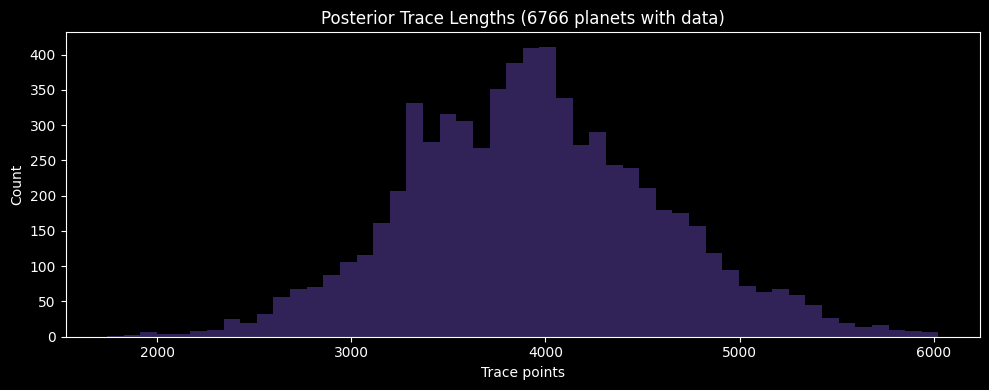

In [24]:
trace_lens = np.array([trace[k]['tracedata'].shape[0] for k in valid_trace_keys])
print(f'min: {trace_lens.min()}, max: {trace_lens.max()}, median: {np.median(trace_lens):.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(trace_lens, bins=50, alpha=0.7, edgecolor='none')
ax.set_xlabel('Trace points')
ax.set_ylabel('Count')
ax.set_title(f'Posterior Trace Lengths ({len(valid_trace_keys)} planets with data)')
plt.tight_layout()
plt.show()

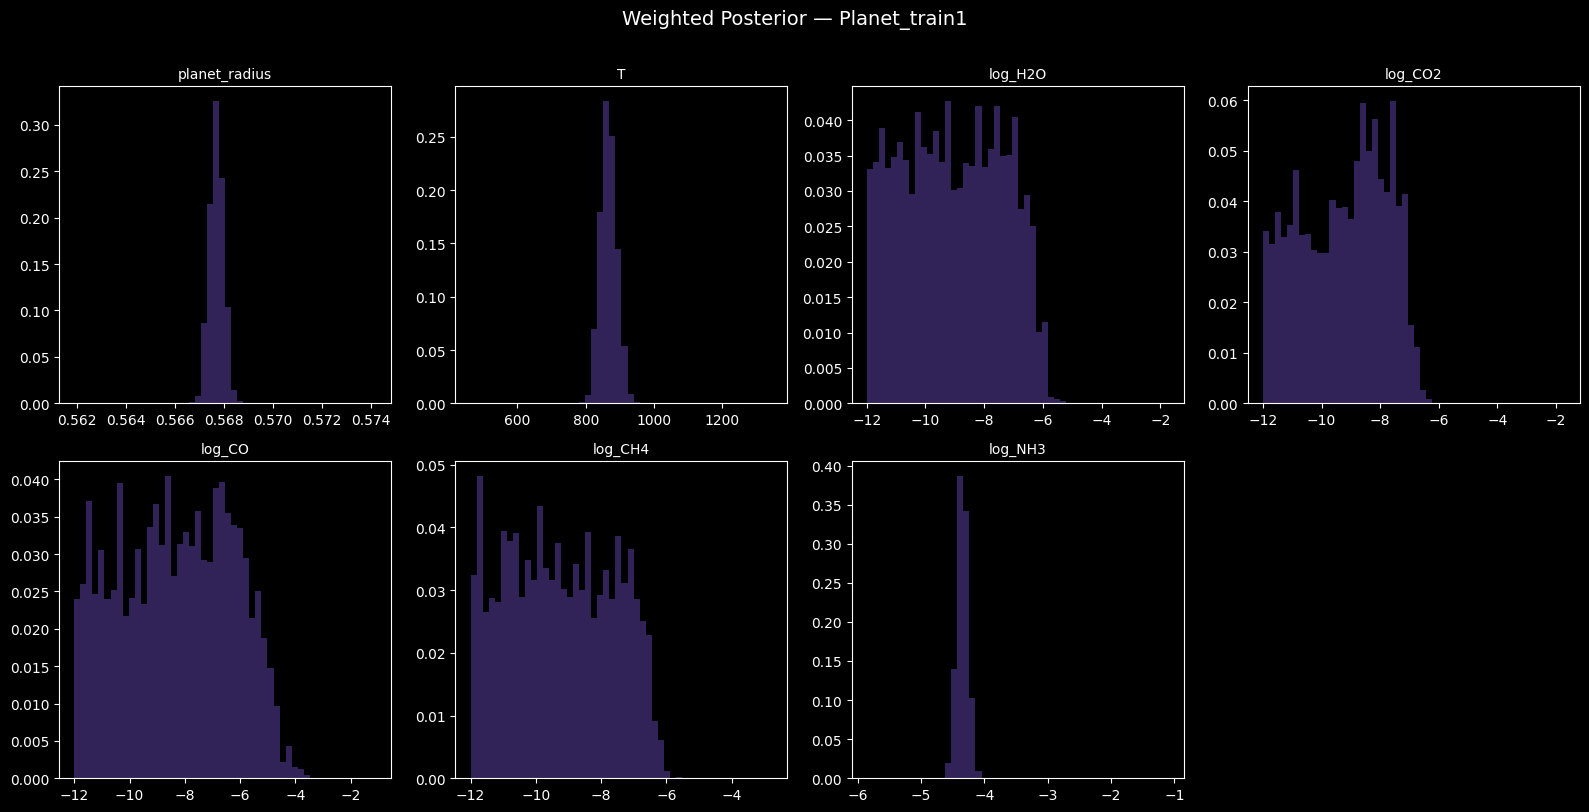

In [25]:
param_names = ['planet_radius', 'T', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
td = trace[k0]['tracedata'][:]
wt = trace[k0]['weights'][:].flatten()
wt = wt / wt.sum()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (ax, name) in enumerate(zip(axes.flat[:7], param_names)):
    if i < td.shape[1]:
        ax.hist(td[:, i], weights=wt, bins=50, alpha=0.7, edgecolor='none')
        ax.set_title(name, fontsize=10)
axes.flat[-1].set_visible(False)
plt.suptitle(f'Weighted Posterior — {k0}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Train vs Test

In [26]:
aux_test = pd.read_csv(TEST / 'AuxillaryTable.csv')
print(f'Train: {aux_train.shape}, Test: {aux_test.shape}')
print(f'Test columns: {aux_test.columns.tolist()}')
aux_test.head()

Train: (41423, 9), Test: (685, 9)
Test columns: ['planet_ID', 'star_distance', 'star_mass_kg', 'star_radius_m', 'star_temperature', 'planet_mass_kg', 'planet_orbital_period', 'planet_distance', 'planet_surface_gravity']


,planet_ID,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity
0,public1,283.803,1.465591e+30,9.322380e+08,4803.0,2.509420e+27,3.550585,0.041144,32.771225
1,public2,223.465,2.230747e+30,1.426067e+09,6115.0,6.409426e+26,19.148095,0.145546,8.370251
2,public3,1516.960,3.313486e+30,1.690551e+09,7366.0,2.486766e+27,0.554233,0.015655,32.475379
3,public4,542.026,2.087383e+30,1.071378e+09,5999.1,6.496475e+26,3.007820,0.041445,8.483931
4,public5,597.937,1.804935e+30,8.835390e+08,5652.8,5.408769e+26,6.508121,0.066053,7.063465


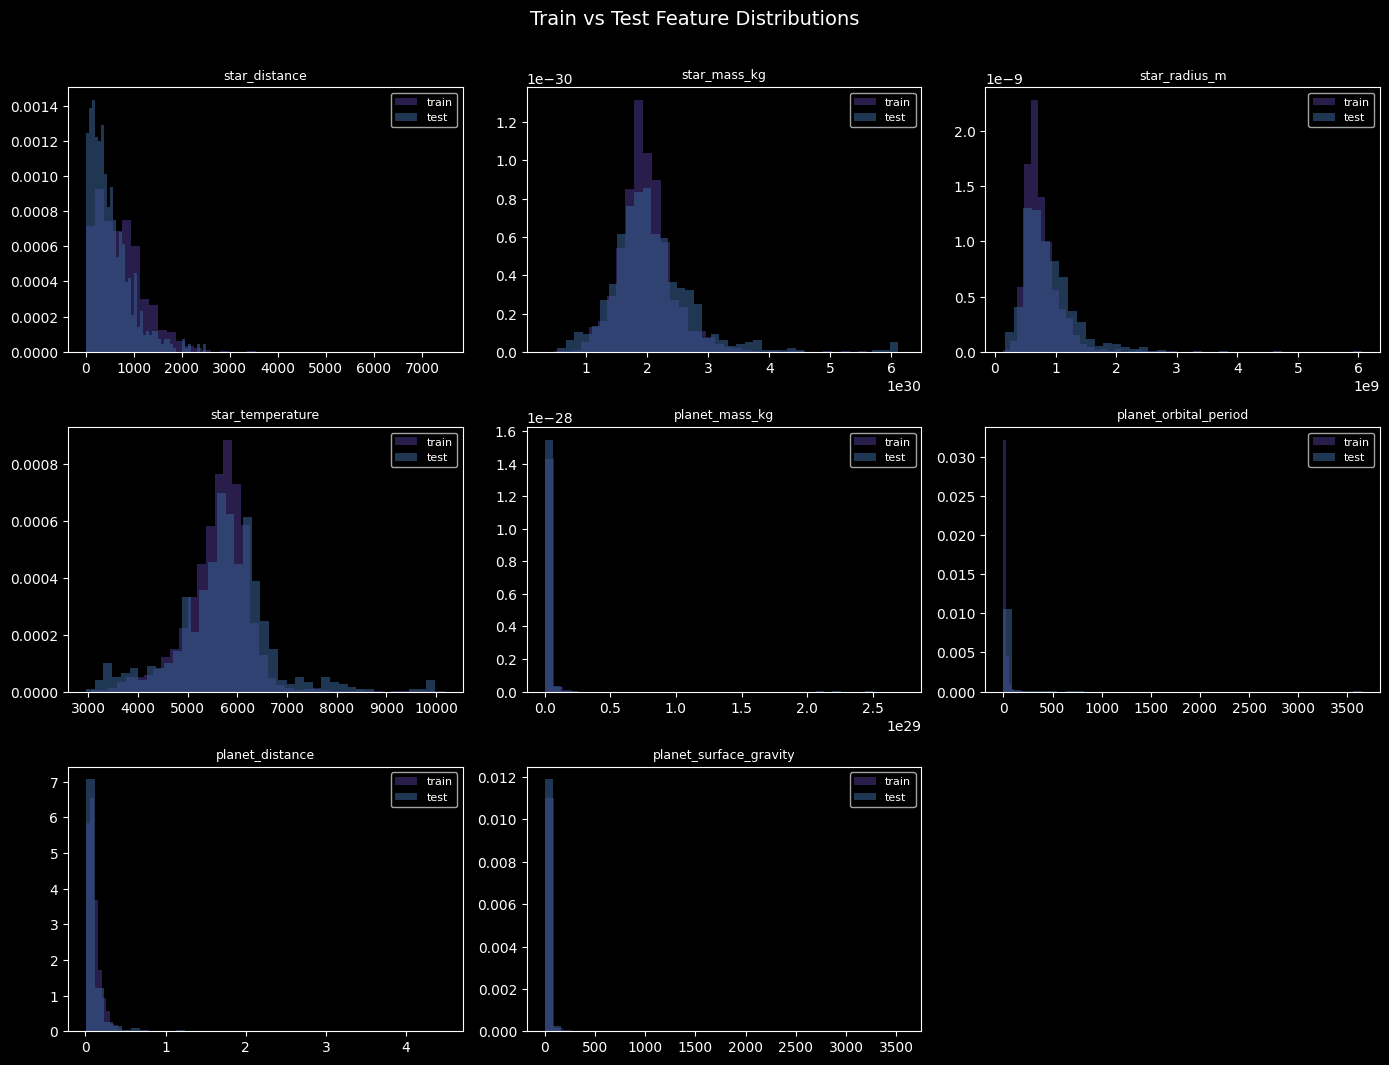

In [27]:
shared = [c for c in feat_cols if c in aux_test.columns]
nrows = (len(shared) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(14, 3.5 * nrows))
for i, (ax, col) in enumerate(zip(axes.flat, shared)):
    ax.hist(aux_train[col].dropna(), bins=40, alpha=0.6, label='train', density=True)
    ax.hist(aux_test[col].dropna(), bins=40, alpha=0.6, label='test', density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=8)
for j in range(i + 1, len(axes.flat)):
    axes.flat[j].set_visible(False)
plt.suptitle('Train vs Test Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Summary

| | Train | Test |
|-|-------|------|
| **Planets** | 41,423 | 685 |
| **Spectra** | `SpectralData.hdf5` (181MB) | `SpectralData.hdf5` (3MB) |
| **Metadata** | `AuxillaryTable.csv` (8 features) | `AuxillaryTable.csv` (8 features) |
| **Quartiles** | all 41,423 | **NONE** |
| **FM params** | all 41,423 | **NONE** |
| **Posteriors** | 6,766 / 41,423 (16.3%) — rest empty | **NONE** |
| **Spectra shape** | (41423, 52, 4) | (685, 52, 4) |

### Targets: 7 parameters
planet_radius, T, log_H2O, log_CO2, log_CO, log_CH4, log_NH3

### Key notes
- Quartiles and FM params available for ALL train planets
- Full posteriors (tracedata) only for ~16% of train planets
- Test: spectra + features only, no labels
- planet_ID format: string like "train1", "train2", ... / "test1", "test2", ...
- HDF5 keys: `Planet_{planet_ID}` (e.g. `Planet_train1`)
- Tracedata subkeys: lowercase `tracedata`, `weights`
- Scoring: 80% posterior (KS test) + 20% spectral (Huber loss), max 1000

In [28]:
trace.close()